Load Dataset and Checkpoint

In [ ]:
# from sklearn.preprocessing import MinMaxScaler
import torch
import numpy as np
import itertools
from pathlib import Path

base_dir = Path.cwd().parent #code folder

Reso=4
Ratio = 0.9
latent_dim = 300
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
conditions = np.load(file=base_dir/"dataset/X_WC_3500.npy") # atomic concentration (condition)
conditions = np.concatenate((conditions[:,:2,:,:,:], conditions[:,3:,:,:,:]), axis=1)
stress = np.load(file=base_dir/"dataset/Y_WC_3500.npy") # virial stress (input)
N_atom=len(conditions)
conditions_train = torch.Tensor(conditions[:int(N_atom*Ratio),:,:,:,:]).to(DEVICE)
stress_train = torch.Tensor(stress[:int(N_atom*Ratio),:,:,:,:]).to(DEVICE)
print(N_atom)

In [ ]:
np.load("D:\plot\code_release\dataset\block_averaged_data\INPUT_train1-500WCrandom.npy").shape

In [ ]:
## test the results
from sklearn.preprocessing import MinMaxScaler
# from CVAE7 import *
import numpy as np
import torch
import importlib
import math

conditions_test = torch.Tensor(conditions[int(N_atom*Ratio):][:][:][:][:]).to(DEVICE) #归一化后
stress_test = torch.Tensor(stress[int(N_atom*Ratio):][:][:][:][:]).to(DEVICE)
# nu_try='1209CVAEWC_3' # load your checkpoint here
MODEL = importlib.import_module(f'checkpoint.{nu_try}.CVAEWC')
model = MODEL.CVAE(6,2,9,latent_dim)
model.eval()

# checkpoint = torch.load(f'/home/nyanac/stress_predt2/VAE/checkpoint/{nu_try}/{nu_try}.tar', map_location=DEVICE) # load your checkpoint here
model.load_state_dict(checkpoint["state_dict"])
model.to(DEVICE)
stress_predt, mu, logvar, Nconcen_p, Nconcen_t, NSRO_p, NSRO_t = model(stress_test, conditions_test[:,:2,:,:,:], conditions_test[:,2:,:,:,:])
# stress_predt, mu, logvar = model(stress_test)
sum(p.numel() for p in model.parameters() if p.requires_grad) # number of parameters needs to be trained

Evaluate the Performace of AlloyVAE on Testset

In [ ]:
import itertools
import matplotlib.pyplot as plt
erro = []
for i in range(int(N_atom*(1-Ratio))):
    diff = stress_predt[i]-stress_test[i]
    for j in itertools.product(range(6), range(Reso), range(Reso), range(Reso)):
        if stress_test[i][j[0]][j[1]][j[2]][j[3]] >= 0.01:
            mr = abs(diff[j[0]][j[1]][j[2]][j[3]]/stress_test[i][j[0]][j[1]][j[2]][j[3]]).cpu().detach().numpy()
            erro.append(mr)
print('MRE in test set：',np.mean(erro))

bin_width = 0.4/100
bins = np.arange(0, 0.4 + bin_width, bin_width)
plt.hist(erro, bins, edgecolor='black')
plt.text(0.4, 0.85, f"mean relative error = {np.mean(erro):.4f}", transform=plt.gca().transAxes)
plt.xlabel('mean relative error')
plt.ylabel('Frequency')
plt.xlim(0, .4)
plt.show()

In [ ]:
# load your data
# mse_recon = np.load(file=f"/home/nyanac/stress_predt2/VAE/checkpoint/{nu_try}/MseReconStore.npy") 
# mse_concen = np.load(file=f"/home/nyanac/stress_predt2/VAE/checkpoint/{nu_try}/MseConcenStore.npy") 
# mse_wc = np.load(file=f"/home/nyanac/stress_predt2/VAE/checkpoint/{nu_try}/MseSROStore.npy") 
# KLD = np.load(file=f"/home/nyanac/stress_predt2/VAE/checkpoint/{nu_try}/KLDStore.npy") 
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 4))
x_axis1 = range(len(mse_recon))
ax1.plot(x_axis1, mse_recon, label='Reconstruction Loss')
# ax1.plot(x_axis1, L_D)
ax1.set_xlabel('epoch')
ax1.set_ylabel('loss')
ax1.legend()

ax2.plot(x_axis1, mse_concen, label='Concentration Prediction Loss')
# ax1.plot(x_axis1, L_D)
ax2.set_xlabel('epoch')
ax2.set_ylabel('loss')
# ax2.set_ylim(0.00001,0.03)
ax2.legend()

ax3.plot(x_axis1, mse_wc, label='WC Prediction Loss')
# ax1.plot(x_axis1, L_D)
ax3.set_xlabel('epoch')
ax3.set_ylabel('loss')
# ax2.set_ylim(0.00001,0.03)
ax3.legend()


x_axis2 = range(len(KLD))
ax4.plot(x_axis2, KLD, label='KLD Loss')
# ax1.plot(x_axis1, L_D)
ax4.set_xlabel('epoch')
ax4.set_ylabel('loss')
# ax3.set_ylim(0.001,0.12)
ax4.legend()

In [ ]:
# Reconstruction of Redisual Stress
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.cm as cm

N=8
i_s = 5
# Create axis
axes = [Reso, Reso, Reso]
# Create Data
data1 = np.ones(axes, dtype=bool)
data2 = np.ones(axes, dtype=bool)
# Control Transparency
alpha = 1
# Control colour
colors1 = np.empty(axes + [4], dtype=np.float32)
colors2 = np.empty(axes + [4], dtype=np.float32)
reds_cmap = cm.get_cmap('Reds')
for i,j,k in itertools.product(range(Reso),range(Reso), range(Reso)):
    value1 = stress_test[N,i_s,i,j,k].cpu().detach().numpy()
    value2 = stress_predt[N,i_s,i,j,k].cpu().detach().numpy()
    colors1[i,j,k,:] = np.array(reds_cmap(value1)[:4])
    colors2[i,j,k,:] = np.array(reds_cmap(value2)[:4])
# Plot figure

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ax1=axes[0]
ax1 = fig.add_subplot(121, projection='3d')
ax1.voxels(data1, facecolors=colors1, edgecolors='grey')
ax1.xaxis.set_ticklabels([])
ax1.yaxis.set_ticklabels([])
ax1.zaxis.set_ticklabels([])
ax1.view_init(elev=30, azim=-45)
ax1.grid(False)
ax1.axis('off') 

ax2=axes[1]
ax2 = fig.add_subplot(122, projection='3d')
ax2.voxels(data2, facecolors=colors2, edgecolors='grey')
ax2.xaxis.set_ticklabels([])
ax2.yaxis.set_ticklabels([])
ax2.zaxis.set_ticklabels([])
ax2.view_init(elev=30, azim=-45)
ax2.grid(False)
ax2.axis('off') 
plt.axis('off')
plt.subplots_adjust(wspace=.25)
plt.show()


In [ ]:
# Reconstruction of Redisual Stress
import numpy as np
import matplotlib.pyplot as plt

concen_face = np.zeros((Reso,Reso))
stress_true_face= np.zeros((Reso,Reso))
stress_predt_face = np.zeros((Reso,Reso))
N = 30 #number N_th atom
iax = 0 #number iax_th information
i_face=1

# concen_laten = concentra_test[N,iax,i_face,:,:]
for j,k in itertools.product(range(Reso), range(Reso)):
    concen_face[j][k] = conditions_test[N][iax][j][i_face][k]
    stress_true_face[j][k] = stress_test[N][iax][j][i_face][k]
    stress_predt_face[j][k] = stress_predt[N][iax][j][i_face][k]

concen_face = concen_face.T
stress_true_face = stress_true_face.T
stress_predt_face = stress_predt_face.T
cmap = plt.cm.get_cmap('Reds') 

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax0 = axes[0]
ax0.set_title('concentration')
ax0.tick_params(axis='both', which='both', length=0)
for i in range(Reso):
    for j in range(Reso):
        value = concen_face[i][j]
        color = cmap(value)
        rect = plt.Rectangle((j, i), 1, 1, facecolor=color)
        ax0.add_patch(rect)
        ax0.set_xlim(0, Reso)
        ax0.set_ylim(0, Reso)
        ax0.set_aspect('equal')
        ax0.xaxis.set_ticklabels([])
        ax0.yaxis.set_ticklabels([])

ax1 = axes[1]
ax1.set_title('reference')
ax1.tick_params(axis='both', which='both', length=0)
for i in range(Reso):
    for j in range(Reso):
        value = stress_true_face[i][j]
        color = cmap(value)
        rect = plt.Rectangle((j, i), 1, 1, facecolor=color)
        ax1.add_patch(rect)

ax2 = axes[2]
ax2.set_title('prediction')
ax2.tick_params(axis='both', which='both', length=0)
for i in range(Reso):
    for j in range(Reso):
        value = stress_predt_face[i][j]
        color = cmap(value)
        rect = plt.Rectangle((j, i), 1, 1, facecolor=color)
        ax2.add_patch(rect)

img2 = ax2.imshow(stress_predt_face, cmap=cmap) 
cbar=fig.colorbar(img2, ax=ax2)
cbar.mappable.set_clim(0, 1)


for ax in axes[1:]:
    ax.set_xlim(0, Reso)
    ax.set_ylim(0, Reso)
    ax.set_xticks(range(Reso + 1))
    ax.set_yticks(range(Reso + 1))
    ax.xaxis.set_ticklabels([])
    ax.yaxis.set_ticklabels([])
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()


In [ ]:
# Reconstruction of Redisual Stress
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def gaussion(x,mu,sigma):
    y = np.exp(-((x - mu)**2)/(2*sigma**2)) / (sigma * np.sqrt(2*np.pi))
    return y

mean1 = torch.mean(stress_test).cpu().detach().numpy()
std1 = np.std(stress_test.cpu().detach().numpy())

mean2 = torch.mean(stress_predt).cpu().detach().numpy()
std2 = np.std(stress_predt.cpu().detach().numpy())

x = np.linspace(0, 1, 100)

y1 = gaussion(x, mean1, std1)

y2 = gaussion(x, mean2, std2)

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

ax2.plot(x, y1, label='reference')

ax2.plot(x, y2, label='prediction')
ax2.set_ylim(0, 4)
ax2.set_ylabel('probability density')

true = stress_test.cpu().detach().numpy().flatten()
predt = stress_predt.cpu().detach().numpy().flatten()
bins = np.linspace(0, 1, num=50)

hist1, _ = np.histogram(true, bins=bins)
hist2, _ = np.histogram(predt, bins=bins)

ax1.hist(true, bins=bins, alpha=0.5, label='Reference')
ax1.hist(predt, bins=bins, alpha=0.5, label='Prediction')
ax1.set_ylabel('frequency')

ax1.legend()
ax2.legend()
plt.show()
print('mean_ref:',mean1)
print('std_ref:',std1)
print('mean_pre:',mean2)
print('std_pre:',std2)

In [ ]:
# Reconstruction of Redisual Stress
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
atom=3
ref = stress_test.cpu().detach().numpy().flatten().reshape(-1,1)
pre = stress_predt.cpu().detach().numpy().flatten().reshape(-1,1)


regressor = LinearRegression()
regressor.fit(ref, pre)
y_pred = regressor.predict(ref)
r2 = regressor.score(pre, y_pred)
print("R-squared (using Scikit-learn):", r2)
print('regression coefficient：', regressor.coef_)

X_new = np.array([[0], [1]])
y_true = X_new
y_regression = regressor.predict(X_new)
plt.scatter(ref, pre, s=1)
plt.plot(X_new, y_true, color='red', label='y=x')

plt.text(0.1, 0.9, f"R² = {r2:.2f}", transform=plt.gca().transAxes)

plt.xlabel('reference')
plt.ylabel('prediction')
plt.xlim([-0, 1]) 
plt.ylim([-0, 1]) 
plt.show()

In [ ]:
# Prediction of Concentration
import itertools
import matplotlib.pyplot as plt

model.eval()

mu, logvar, Nconcen_predt, NSRO_predt = model.encoder(stress_test) # Nconcen_predt is the reference for the final evaluation
Nconcen_test = model.smoother_c(conditions_test[:,:2,:,:,:]).cpu().detach().numpy()
Nconcen_predt = Nconcen_predt.cpu().detach().numpy()
NSRO_test = model.smoother_w(conditions_test[:,2:,:,:,:]).cpu().detach().numpy()
NSRO_predt = NSRO_predt.cpu().detach().numpy()
erro = []
for i in range(int(N_atom*(1-Ratio))):
    diff = Nconcen_predt[i]-Nconcen_test[i]
    for j in range(len(Nconcen_test[0])):
        if Nconcen_test[i][j] >= 0.01:
            mr = abs(diff[j]/Nconcen_test[i][j])
            erro.append(mr)
print('MRE in test dataset：',np.mean(erro))

plt.figure(figsize=(6, 5))
bin_width = 0.4/100
bins = np.arange(0, 0.4 + bin_width, bin_width)
plt.hist(erro, bins, edgecolor='black')

plt.text(0.4, 0.85, f"mean relative error = {np.mean(erro):.4f}", transform=plt.gca().transAxes)
plt.xlabel('mean relative error')
plt.ylabel('Frequency')
plt.xlim(0, .4) 

plt.show()

In [ ]:
mean_mu = torch.mean(mu, axis=1).cpu().detach().numpy()
plt.figure(figsize=(8, 6))
plt.hist(mean_mu, bins=10, edgecolor='black', alpha=0.7)
plt.title('Frequency Distribution of Mean Values')
plt.xlabel('Mean Value')
plt.ylabel('Frequency')
# plt.xlim(-0.0005, 0.0005)
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
std = torch.exp(0.5 * logvar)
mean_mu = torch.mean(std, axis=1).cpu().detach().numpy()
plt.figure(figsize=(8, 6))
plt.hist(mean_mu, bins=10, edgecolor='black', alpha=0.7)
plt.title('Frequency Distribution of Mean Values')
plt.xlabel('Mean Value')
plt.ylabel('Frequency')
# plt.xlim(-0.0005, 0.0005)
plt.grid(axis='y', alpha=0.75)
plt.show()

In [ ]:
import numpy as np
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.decomposition import KernelPCA
from sklearn.manifold import LocallyLinearEmbedding
from sklearn.manifold import Isomap
import matplotlib.pyplot as plt
import umap
import seaborn as sns

NSRO_test_reshaped = NSRO_test.reshape(len(NSRO_test), -1)
NSRO_predt_reshaped = NSRO_predt.reshape(len(NSRO_predt), -1)

pca = PCA(n_components=2)
# tsne = TSNE(n_components=2, random_state=20)
# X_2d = tsne.fit_transform(Nconcen_train_reshaped)
# isomap = Isomap(n_components=2, n_neighbors=22)
X_2d_r = pca.fit_transform(NSRO_test_reshaped)
X_2d_p = pca.fit_transform(NSRO_predt_reshaped)

Nconcen_test_reshaped = Nconcen_test.reshape(len(Nconcen_test), -1)
Nconcen_predt_reshaped = Nconcen_predt.reshape(len(Nconcen_predt), -1)

# isomap = Isomap(n_components=2, n_neighbors=14)
Xc_2d_r = pca.fit_transform(Nconcen_test_reshaped)
Xc_2d_p = pca.fit_transform(Nconcen_predt_reshaped)



fig, axs = plt.subplots(1, 2, figsize=(12, 5))
# plt.scatter(X_2d, Y_2d)
axs[0].scatter(Xc_2d_r[:, 0], Xc_2d_r[:, 1],s=14,color="b",label="reference")
axs[0].scatter(Xc_2d_p[:, 0], Xc_2d_p[:, 1],s=14,color="r",label="prediction")
axs[0].set_title('PCA Visualization of smoothed concen')
axs[0].set_xlabel('Component 1')
axs[0].set_ylabel('Component 2')
axs[0].legend()

axs[1].scatter(X_2d_r[:, 0], X_2d_r[:, 1],s=14,color="b",label="reference")
axs[1].scatter(X_2d_p[:, 0], X_2d_p[:, 1],s=14,color="r",label="prediction")
axs[1].set_title('PCA Visualization of smoothed concen')
axs[1].set_xlabel('Component 1')
axs[1].set_ylabel('Component 2')
axs[1].legend()

plt.show()

In [ ]:
# Prediction of Concentration
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

ref = Nconcen_test.flatten().reshape(-1,1)
pre = Nconcen_predt.flatten().reshape(-1,1)


regressor = LinearRegression()
regressor.fit(ref, pre)
y_pred = regressor.predict(ref)
r2 = regressor.score(pre, y_pred)
print("R-squared (using Scikit-learn):", r2)
print('regression coefficient：', regressor.coef_)

X_new = np.array([[0], [1]])
y_true = X_new
y_regression = regressor.predict(X_new)
plt.scatter(ref, pre, s=1)
plt.plot(X_new, y_true, color='red', label='y=x')
# plt.plot(X_new, y_regression, color='yellow', label='Fitted Line')

plt.text(0.1, 0.9, f"R² = {r2:.2f}", transform=plt.gca().transAxes)

plt.xlim([-0, 1]) 
plt.ylim([-0, 1]) 
# 显示图表
plt.show()

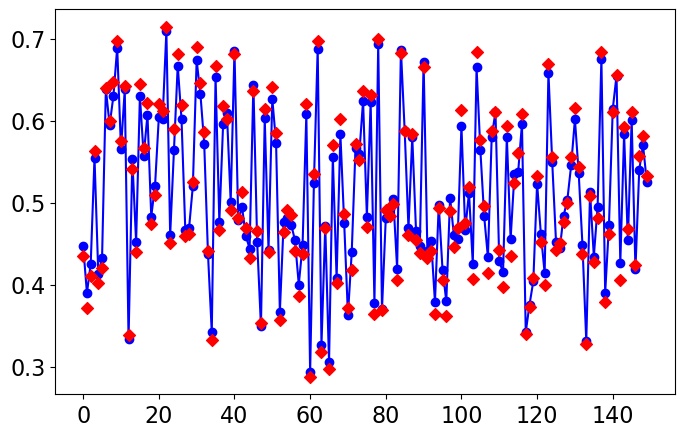

In [ ]:
# Prediction of Concentration
x = np.arange(len(Nconcen_test[0]))
i_concen =84
y1 = Nconcen_test[i_concen]       
y2 = Nconcen_predt[i_concen]         

plt.figure(figsize=(8, 5))
plt.plot(x, y1, label='reference', marker='o', color='b') 
plt.scatter(x, y2, label='predt', marker='D', color='r', zorder=5) 
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()

In [ ]:
# Prediction of WC
import itertools
import matplotlib.pyplot as plt

erro = []
for i in range(int(N_atom*(1-Ratio))):
    diff = NSRO_predt[i]-NSRO_test[i]
    for j in range(len(Nconcen_test[0])):
        if NSRO_test[i][j] >= 0.01:
            mr = abs(diff[j]/NSRO_test[i][j])
            erro.append(mr)
print('MRE in test set：',np.mean(erro))
plt.figure(figsize=(6, 5))
bin_width = 0.4/100
bins = np.arange(0, 0.4 + bin_width, bin_width)
plt.hist(erro, bins, edgecolor='black')
plt.text(0.4, 0.85, f"mean relative error = {np.mean(erro):.4f}", transform=plt.gca().transAxes)
plt.xlabel('mean relative error')
plt.ylabel('Frequency')
plt.xlim(0, .4) 
plt.show()

In [ ]:
# Prediction of WC
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


i_sro = 0
ref = NSRO_test.flatten().reshape(-1,1)
pre = NSRO_predt.flatten().reshape(-1,1)

regressor = LinearRegression()
regressor.fit(ref, pre)
y_pred = regressor.predict(ref)
r2 = regressor.score(pre, y_pred)
print("R-squared (using Scikit-learn):", r2)
print('regression coefficient：', regressor.coef_)

X_new = np.array([[0], [1]])
y_true = X_new
y_regression = regressor.predict(X_new)
plt.scatter(ref, pre, s=1)
plt.plot(X_new, y_true, color='red', label='y=x')
plt.text(0.1, 0.9, f"R² = {r2:.2f}", transform=plt.gca().transAxes)
plt.xlim([-0, 1]) 
plt.ylim([-0, 1]) 
plt.show()

In [ ]:
# Prediction of Concentration
x = np.arange(len(NSRO_test[0])) 
i_sro = 84
y1 = NSRO_test[i_sro]     
y2 = NSRO_predt[i_sro]      
plt.figure(figsize=(8, 5))
plt.plot(x, y1, label='reference', marker='o', color="b") 
plt.scatter(x, y2, label='predt', marker='D',color="r", zorder=5) 
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()

Stress prediction through self-checking process

In [ ]:
#stress_prediction through self-checking process
model.eval()
N_try = 1000
i_predt = 33
accum = 0
final_predt=[]
selfcheck_c = []
selfcheck_w = []
ERRO = []
for k in range(N_try):
    # print("process",k+1)
    noise = torch.randn(1, latent_dim).to(DEVICE) 
    stress_generate = model.decoder(noise, 
                                    torch.Tensor(Nconcen_test[i_predt]).unsqueeze(0).to(DEVICE), 
                                    torch.Tensor(NSRO_test[i_predt]).unsqueeze(0).to(DEVICE))
    mu, logvar, Nconcen_predt_generate, NSRO_predt_generate= model.encoder(stress_generate)
    erro = []
    diff = Nconcen_predt_generate.cpu().detach().numpy()-Nconcen_test[i_predt].reshape(1, len(Nconcen_test[0]))
    for j in range(len(Nconcen_test[0])):
        if Nconcen_test[i_predt][j] >= 0.01:
            mr = abs(diff[0][j]/Nconcen_test[i_predt][j])
            erro.append(mr)
    ERRO.append(np.mean(erro))
    if np.mean(erro)>=0.04:
        continue

    erro = []
    diff = NSRO_predt_generate.cpu().detach().numpy()-NSRO_test[i_predt].reshape(1, len(Nconcen_test[0]))
    for j in range(len(Nconcen_test[0])):
        if NSRO_test[i_predt][j] >= 0.01:
            mr = abs(diff[0][j]/NSRO_test[i_predt][j])
            erro.append(mr)
    if np.mean(erro)>=0.04:
        continue

    accum = accum + 1
    selfcheck_c.append(Nconcen_predt_generate.cpu().detach().numpy())
    selfcheck_w.append(NSRO_predt_generate.cpu().detach().numpy())
    final_predt.append(stress_generate.cpu().detach().numpy())
print(accum)

In [ ]:
# Import libraries
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.cm as cm

i_generate =4
axes = [Reso, Reso, Reso]
# Create Data
data1 = np.ones(axes, dtype=bool)
data2 = np.ones(axes, dtype=bool)
# Control Transparency
alpha = 1
# Control colour
colors1 = np.empty(axes + [4], dtype=np.float32)
colors2 = np.empty(axes + [4], dtype=np.float32)
reds_cmap = cm.get_cmap('Reds')
for i,j,k in itertools.product(range(Reso),range(Reso), range(Reso)):
    value1 = stress_test[i_predt,0,i,j,k].cpu().detach().numpy()
    value2 = final_predt[i_generate][0,0,i,j,k]
    colors1[i,j,k,:] = np.array(reds_cmap(value1)[:4])
    colors2[i,j,k,:] = np.array(reds_cmap(value2)[:4])
# Plot figure

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ax1=axes[0]
ax1 = fig.add_subplot(121, projection='3d')
ax1.voxels(data1, facecolors=colors1, edgecolors='grey')
ax1.xaxis.set_ticklabels([])
ax1.yaxis.set_ticklabels([])
ax1.zaxis.set_ticklabels([])
ax1.view_init(elev=30, azim=-45)
ax1.grid(False)
ax1.axis('off') 

ax2=axes[1]
ax2 = fig.add_subplot(122, projection='3d')
ax2.voxels(data2, facecolors=colors2, edgecolors='grey')
ax2.xaxis.set_ticklabels([])
ax2.yaxis.set_ticklabels([])
ax2.zaxis.set_ticklabels([])
ax2.view_init(elev=30, azim=-45)
ax2.grid(False)
ax2.axis('off') 
plt.axis('off')
plt.subplots_adjust(wspace=.25)
# plt.savefig(f'/home/nyanac/stress_predt2/VAE/checkpoint/{nu_try}/Final_Predt_{i_predt}_{i_generate}.png')
# plt.savefig(f'/home/nyanac/stress_predt2/VAE/checkpoint/{nu_try}/FigS7/Final_Predt_{i_predt}_{i_generate}.svg', format='svg')
plt.show()

In [ ]:
# evaluation the prediction
erro = []
diff = selfcheck_c[i_generate]-Nconcen_test[i_predt]
for j in range(40):
    if Nconcen_test[i_predt][j] >= 0.01:
        mr = abs(diff[0][j]/Nconcen_test[i_predt][j])
        erro.append(mr)
print('MRE：',np.mean(erro))
x = np.arange(len(NSRO_test[0])) 

y1 = Nconcen_test[i_predt]        
y2 = selfcheck_c[i_generate]         
plt.figure(figsize=(8, 5))
plt.plot(x, y1, label='reference', marker='o', color="b")  
plt.scatter(x, y2[0], label='predt', marker='D',color="r",zorder=5)  

plt.title('Line Plot of Two Arrays')
plt.xlabel('latent index')
plt.ylabel('Values')

plt.text(0.1, 0.1, f"mean relative error = {np.mean(erro):.4f}", transform=plt.gca().transAxes)
# plt.savefig(f'/home/nyanac/stress_predt2/VAE/checkpoint/{nu_try}/Selfcheck_concen{i_predt}_{i_generate}.png')
# plt.savefig(f'/home/nyanac/stress_predt2/VAE/checkpoint/{nu_try}/FigS7/Selfcheck_concen{i_predt}_{i_generate}.svg', format='svg')
plt.show()

In [ ]:
# evaluation the prediction

erro = []
diff = selfcheck_w[i_generate]-NSRO_test[i_predt]
for j in range(40):
    if NSRO_test[i_predt][j] >= 0.01:
        mr = abs(diff[0][j]/NSRO_test[i_predt][j])
        erro.append(mr)
print('MRE：',np.mean(erro))
x = np.arange(len(NSRO_test[0])) 

y1 = NSRO_test[i_predt]      
y2 = selfcheck_w[i_generate]        
plt.figure(figsize=(8, 5))
plt.plot(x, y1, label='reference', marker='o', color="b")  
plt.scatter(x, y2[0], label='predt', marker='D',color="r",zorder=5) 


plt.title('Line Plot of Two Arrays')
plt.xlabel('latent index')
plt.ylabel('Values')
# plt.legend()  
plt.text(0.1, 0.1, f"mean relative error = {np.mean(erro):.4f}", transform=plt.gca().transAxes)
# plt.savefig(f'/home/nyanac/stress_predt2/VAE/checkpoint/{nu_try}/Selfcheck_sro{i_predt}_{i_generate}.png')
# plt.savefig(f'/home/nyanac/stress_predt2/VAE/checkpoint/{nu_try}/FigS7/Selfcheck_sro{i_predt}_{i_generate}.svg', format='svg')
plt.show()

Optimization Analysis

In [ ]:
import numpy as np
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.decomposition import KernelPCA
from sklearn.manifold import LocallyLinearEmbedding
from sklearn.manifold import Isomap
import matplotlib.pyplot as plt
import umap
import seaborn as sns

# load your data
# index = "1000_1229_changenoise"
# s_values = np.load(file=f"/home/nyanac/stress_predt2/VAE/checkpoint/{nu_try}/optimize_c/{index}/S.npy") 
# C_O = np.load(file=f"/home/nyanac/stress_predt2/VAE/checkpoint/{nu_try}/optimize_c/{index}/C.npy") 
# VAR_O = np.load(file=f"/home/nyanac/stress_predt2/VAE/checkpoint/{nu_try}/optimize_c/{index}/V_TAU.npy") 

c_calues_total = np.concatenate((conditions_train[:,:2,:,:,:].cpu(), C_O), axis=0)
VAR_T = np.zeros((len(conditions_train), 1))
for i in range(len(conditions_train)):
    tau = (1/math.sqrt(6)) * (stress_train[i,0] - stress_train[i,1] + stress_train[i,4] - stress_train[i,5])
    VAR_T[i] = torch.var(tau.cpu())

var_total = np.concatenate((VAR_T, VAR_O), axis=0)

c_values_reshaped =c_calues_total.reshape(len(c_calues_total), -1)
# NSRO_predt_reshaped = NSRO_predt.reshape(len(NSRO_predt), -1)

# pca = PCA(n_components=2)
# tsne = TSNE(n_components=2, random_state=20)
# X_2d = tsne.fit_transform(Nconcen_train_reshaped)
isomap = Isomap(n_components=2, n_neighbors=21)
# umap_model = umap.UMAP(n_neighbors=60, n_components=2, random_state=42, min_dist=1, learning_rate=1.0, n_epochs=400)
# X_2d_r = pca.fit_transform(c_values_reshaped)
X_2d_r = isomap.fit_transform(c_values_reshaped)
# X_2d_r = umap_model.fit_transform(c_values_reshaped)
# X_2d_r = tsne.fit_transform(c_values_reshaped)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
scatter = axs.scatter(X_2d_r[:, 0], X_2d_r[:, 1],c =var_total ,s=14)
axs.set_title('Isomap Visualization of smoothed concen')
axs.set_xlabel('Component 1')
axs.set_ylabel('Component 2')
axs.legend()
cbar = plt.colorbar(scatter, ax=axs)
cbar.set_label('Variable Value')  
bar_min = cbar.vmin
bar_max = cbar.vmax
plt.show()

In [ ]:
import numpy as np
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.decomposition import KernelPCA
from sklearn.manifold import LocallyLinearEmbedding
from sklearn.manifold import Isomap
import matplotlib.pyplot as plt
import umap
import seaborn as sns

# load your data
# index = "1000_1229_changenoise"
# s_values = np.load(file=f"/home/nyanac/stress_predt2/VAE/checkpoint/{nu_try}/optimize_c/{index}/S.npy") 
# C_O = np.load(file=f"/home/nyanac/stress_predt2/VAE/checkpoint/{nu_try}/optimize_c/{index}/C.npy") 
# VAR_O = np.load(file=f"/home/nyanac/stress_predt2/VAE/checkpoint/{nu_try}/optimize_c/{index}/V_TAU.npy") 


c_values_reshaped =C_O.reshape(len(C_O), -1)
# NSRO_predt_reshaped = NSRO_predt.reshape(len(NSRO_predt), -1)

# pca = PCA(n_components=2)
# tsne = TSNE(n_components=2, random_state=10)
# X_2d = tsne.fit_transform(c_values_reshaped)
isomap = Isomap(n_components=2, n_neighbors=26)
# umap_model = umap.UMAP(n_neighbors=60, n_components=2, random_state=42, min_dist=1, learning_rate=1.0, n_epochs=400)
# X_2d_r = pca.fit_transform(c_values_reshaped)
X_2d_r = isomap.fit_transform(c_values_reshaped)
# X_2d_r = umap_model.fit_transform(c_values_reshaped)
# X_2d_r = tsne.fit_transform(c_values_reshaped)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
scatter = axs.scatter(X_2d_r[:, 0], X_2d_r[:, 1],c =VAR_O ,s=14)
axs.set_title('Isomap Visualization of smoothed concen')
axs.set_xlabel('Component 1')
axs.set_ylabel('Component 2')
axs.legend()
cbar = plt.colorbar(scatter, ax=axs)
cbar.set_label('Variable Value')  # 设置颜色条标签
scatter.set_clim(vmin=bar_min, vmax=bar_max) 
plt.show()

In [ ]:
from sklearn.cluster import KMeans

n_clusters =2 
kmeans = KMeans(n_clusters=n_clusters)
kmeans.fit(X_2d_r)
labels = kmeans.labels_

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_2d_r[:, 0], X_2d_r[:, 1], c=labels, cmap='viridis', marker='o', alpha=0.6)
plt.title('Isomap Dimensionality Reduction and K-means Clustering')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.colorbar(scatter, label='Cluster Label')
plt.show()

In [33]:
label_0 = np.where(labels == 0)[0].tolist()
label_1 = np.where(labels == 1)[0].tolist()

x_new_concen = np.load(file=f"/home/nyanac/stress_predt2/datawithWC/x_new_concen_minmax.npy")[:,:2,:,:,:] # for inverse min-max use only
my_scaler_concen = MinMaxScaler()
x_all_concen = my_scaler_concen.fit_transform(x_new_concen.reshape(len(x_new_concen), 2*4*4*4))
c_inverse = my_scaler_concen.inverse_transform(C_O.reshape(len(C_O), 2*4*4*4)) #inverse transfer
c_inverse = c_inverse.reshape(len(C_O),2,4,4,4)
Cr_concen = np.zeros((len(C_O), 4,4,4))
for i in range((len(C_O))):
    Cr_concen[i] = 1 - c_inverse[i,0,:,:,:] - c_inverse[i,1,:,:,:]
Cr_concen_nor = my_scaler_concen.fit_transform(Cr_concen.reshape(len(Cr_concen), 4*4*4))

print("mean of label_0 Ni",np.mean(C_O[label_0,0,:,:,:]))
print("mean of label_1 Ni",np.mean(C_O[label_1,0,:,:,:]))
print("mean of label_0 Co",np.mean(C_O[label_0,1,:,:,:]))
print("mean of label_1 Co",np.mean(C_O[label_1,1,:,:,:]))
print("mean of label_0 Cr",np.mean(Cr_concen_nor[label_0]))
print("mean of label_1 Cr",np.mean(Cr_concen_nor[label_1]))

mean of label_0 Ni 0.4121885660146799
mean of label_1 Ni 0.5928219936438531
mean of label_0 Co 0.44988334967109495
mean of label_1 Co 0.6075898816840022
mean of label_0 Cr 0.5702127801740503
mean of label_1 Cr 0.4004636859288165


In [ ]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 14  

C_var = []
Ni_mean = []
Co_mean = []
for i in range(len(C_O)):
    C_var.append(np.var(C_O[i]))
    Ni_mean.append(np.mean(C_O[i,0]))
    Co_mean.append(np.mean(C_O[i,1]))

Ctrain_var = []
for i in range(len(conditions_train)):
    Ctrain_var.append(torch.var(conditions_train[i,:2,:,:,:]).cpu())

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].hist(C_var, bins=30, density=False, alpha=0.6, color='r')
axs[0].hist(Ctrain_var, bins=15, density=False, alpha=0.6, color='b')
# axs[0].set_title('Distribution 1')
axs[0].set_xlabel('Concentration Variance')
axs[0].set_ylabel('Frequency')

axs[1].hist(VAR_O, bins=20, density=False, alpha=0.6, color='r')
axs[1].hist(VAR_T, bins=30, density=False, alpha=0.6, color='b')
# axs[1].set_title('Distribution 2')
axs[1].set_xlabel('RSS Variance')
axs[1].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


plt.rcParams['font.family'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


plt.figure(figsize=(8, 6))
plt.rcParams['font.size'] = 14 

# load your data
# data_c = np.load("/home/nyanac/stress_predt2/VAE/checkpoint/1209CVAEWC_3/optimize_c/1000_1229_changenoise/ERRO_C.npy")
# data_w = np.load("/home/nyanac/stress_predt2/VAE/checkpoint/1209CVAEWC_3/optimize_c/1000_1229_changenoise/ERRO_W.npy")

bins = 30
plt.hist(data_c, bins=bins, alpha=0.7, color='#4c72b0', label=r'MRE of $\bar{\mathbf{c}}$')
plt.hist(data_w, bins=bins, alpha=0.7, color='#dd8452', label=r'MRE of $\bar{\mathbf{w}}$')
plt.xlabel('MRE Value', fontsize=18)
plt.ylabel('Frequency', fontsize=18)
plt.legend(loc='upper right', fontsize=18)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
# plt.savefig(f'/home/nyanac/stress_predt2/VAE/checkpoint/1209CVAEWC_3/optimize_c/1000_1229_changenoise/mre.svg', format='svg')
plt.show()